# Preliminaries

In [3]:
import numpy as np
import numpy.polynomial.polynomial as poly

import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import FormatStrFormatter

import scipy.constants as const
from scipy.signal import fftconvolve, welch

import pycbc.psd, pycbc.filter, pycbc.noise
from pycbc.types import TimeSeries

plt.rcParams['text.usetex'] = True

#define the solar mass in [kg] and parsec in [meters]
sol = 1.989e30
pc = 3.086e16

/opt/anaconda3/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


# 1: Function Definitions

First, we redefine the waveforms of the quasi-circular binary system and the quasi-circular Lagrange three-body system so that the waveforms are in SI units and are compatible with the `PyCBC` methods. Following also what is common in the literature, the input masses and distances will be in solar masses and in parsecs, respectively.

In [6]:
#for the waveforms of the quasi-circular binary system and quasi-circular Lagrange triple
import waveforms

print(waveforms.CircularBinary.__doc__)
print(waveforms.CircularLagrangeTriple.__doc__)

CircularBinary contains the waveforms for a quasi-circular binary system up to the 0.5-PN approximation.
    Upon initialization, the user must supply the following parameters of the binary:

    l = initial separation distance in [pc],
    m1, m2 = masses of the individual masses in [solar mass],
    r = distance to the binary system in [pc],
    i_deg = orbital inclination angle in [deg],
    phi = integration constant corresponding to the value of the phase at coalescence [rad]
    

    CircularLagrangeTriple contains the waveforms for a quasi-circular Lagrange three-body system up to the 0.5-PN approximation.
    Upon initialization, the user must supply the following parameters of the binary:

    l = initial separation distance in [pc],
    m1, m2, m3 = masses of the individual masses in [solar mass],
    r = distance to the binary system in [pc],
    i_deg = orbital inclination angle in [deg],
    phi = integration constant corresponding to the value of the phase at coalescence

The following functions are for calculating the parameters of the Lagrange triple that give out the same waveform as that of a given binary system.

In [8]:
def findQuadDegeneracy(a, m1_2B, m2_2B, r_2B, i_2B, M_3B, beta_1):
    M_3B *= sol
    
    binary = waveforms.CircularBinary(a, m1_2B, m2_2B, r_2B, i_2B, 0)
    w_2B = np.sqrt(const.G*binary.M/(binary.l**3))

    r_3B = (binary.r*((const.G*M_3B/(const.c**2))**(5/3))*beta_1*np.abs(3*beta_1 - 1))/((const.G*binary.M_c/(const.c**2))**(5/3))
    b = (const.G*M_3B/(w_2B**2))**(1/3)

    #return b and r_3B in [pc]
    return b/pc, r_3B/pc

def F(b1, b2):
    num = 3*((b1 + b2 - 1)**2)*((2*b1**2 + (b1 + b2)*(2*b2 - 1))**2) + (b1 - 3*b1**2 + 2*b1**3 + b2*(b2*(3 - 2*b2) - 1))**2
    denom = 27*(b1**2)*(b2**2)*((b1 + b2 - 1)**2) + ((b1 - b2)**2)*((2*b1 + b2 - 1)**2)*((b1 + 2*b2 - 1)**2)

    return np.sqrt(num/denom)

def iota(b1, b2, ratio_w_3w):
    return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))

def find_M_3B(a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B, b1):
    binary = waveforms.CircularBinary(a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B)
    
    #quantities obtainable from the known binary system
    amp_quadPlus_2B = binary.h_quad(t_max = 100, ampOnly = True, pol = "plus")
    amp_octcqPlus_2B_w = binary.h_octcq(t_max = 100, ampOnly = True, pol = "plus")[0]
    amp_octcqPlus_2B_3w = binary.h_octcq(t_max = 100, ampOnly = True, pol = "plus")[1]
    w_2B = np.sqrt(const.G*(m1_2B*sol + m2_2B*sol)/((a*pc)**3))

    #parameters obtainable from the equivalent Lagrange triple
    b3 = 1 - 2*b1
    i_3B = np.radians(iota(b1, b1, amp_octcqPlus_2B_w/amp_octcqPlus_2B_3w))

    term1 = (np.sqrt(3)*b3/8)*(amp_quadPlus_2B/amp_octcqPlus_2B_w)*(np.sin(i_3B)*(5 + np.cos(i_3B)**2)/(1 + np.cos(i_3B)**2))*((w_2B/const.c)**(1/3))
    term2 = (9*np.sqrt(27)/8)*(b1*b3/np.abs(b1 - b3))*(amp_quadPlus_2B/amp_octcqPlus_2B_3w)*np.sin(i_3B)*((w_2B/const.c)**(1/3))

    return ((const.c**2)/const.G) * ((1/2)*(term1**(-3)) + (1/2)*(term2**(-3)))

def find_r(a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B, b1):
    t = np.linspace(0, 1000, 10000)
    binary = waveforms.CircularBinary(a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B)
    
    #quantities obtainable from the known binary system
    amp_quadPlus_2B = binary.h_quad(t_max = 100, ampOnly = True, pol = "plus")
    amp_octcqPlus_2B_w = binary.h_octcq(t_max = 100, ampOnly = True, pol = "plus")[0]
    amp_octcqPlus_2B_3w = binary.h_octcq(t_max = 100, ampOnly = True, pol = "plus")[1]
    w_2B = np.sqrt(const.G*(m1_2B*sol + m2_2B*sol)/((a*pc)**3))

    #parameters obtainable from the equivalent Lagrange triple
    i_3B = np.radians(iota(b1, b1, amp_octcqPlus_2B_w/amp_octcqPlus_2B_3w))
    b3 = 1 - 2*b1
    M_3B = find_M_3B(a, m1_2B, m2_2B, r_2B, i_2B_deg, phi_2B, b1)

    term1 = 2*((const.G*M_3B/(const.c**2))**(5/3))*((w_2B/const.c)**(2/3))*b1*np.abs(b1 - b3)*(1 + np.cos(i_3B)**2)
    term2 = (np.sqrt(3)/4)*((const.G*M_3B/(const.c**2))**2)*(w_2B/const.c)*b1*b3*np.abs(b1 - b3)*np.sin(i_3B)*(5 + np.cos(i_3B)**2)
    term3 = (9*np.sqrt(27)/4)*((const.G*M_3B/(const.c**2))**2)*(w_2B/const.c)*(b1**2)*b3*np.sin(i_3B)*(1 + np.cos(i_3B)**2)
    
    return (term1 + term2 + term3)/(amp_quadPlus_2B + amp_octcqPlus_2B_w + amp_octcqPlus_2B_3w)

def findOctDegeneracy(params_2B, beta_1, filename = "", radRxn = False, suppressPrint = False, atol = 1e-23):
    #initialization
    binary = waveforms.CircularBinary(*params_2B)
    
    #generate the data
    ratio_w_3w = binary.h_octcq(t_max = 10, radRxn = False, ampOnly = True, pol = "plus")[0]/binary.h_octcq(t_max = 10, radRxn = False, ampOnly = True, pol = "plus")[1]
    
    b1 = np.linspace(0, 1, 500000)
    b2 = np.linspace(0, 1, 500000)
    i_3B = iota(b1, b2, ratio_w_3w)
    i_3B[b1 > 0.5] = np.nan
    
    #plot M_3B and r_3B for the given binary system
    #find the values of b1 where i_3B is defined (i.e., the values of b1 that are part of the domain of i_3B)
    b1_filtered = b1[np.where(~np.isnan(i_3B))]

    if suppressPrint == False:
        print("Min beta_1 for true degeneracy = {}".format(b1_filtered[0]))
        print("Max beta_1 for true degeneracy = {}".format(b1_filtered[-1]))

    if b1_filtered[0] < beta_1 < b1_filtered[-1]:
        #calculate the parameters obtainable from the given binary system      
        w_2B = np.sqrt(const.G*(params_2B[1]*sol + params_2B[2]*sol)/((params_2B[0]*pc)**3))

        #find the parameters of the equivalent Lagrange triple
        M_3B = find_M_3B(*params_2B, beta_1)
        r_3B = find_r(*params_2B, beta_1)
        b = (const.G*M_3B/(w_2B**2))**(1/3)
        m1_3B = M_3B*beta_1
        m3_3B = M_3B - 2*m1_3B
        i_3B_deg = iota(beta_1, beta_1, ratio_w_3w)

        delta_t = 1/5000
        t_max = 3
        phi_3B = 0
        shift = np.linspace(0, 2*np.pi, 1000)

        for phi in shift:
            temp = [b/pc, m1_3B/sol, m1_3B/sol, m3_3B/sol, r_3B/pc, i_3B_deg, phi]
            lagrange = waveforms.CircularLagrangeTriple(*temp)
            check = np.abs(binary.h_octcq(t_max, delta_t, radRxn = True, pol = "plus")[:4] - lagrange.h_octcq(t_max, delta_t, radRxn = True, pol = "plus")[:4])
            
            if all(np.isclose(check, 0, atol = atol)):
                phi_3B = phi

        #compile the parameters of the triple into one list
        return [b/pc, m1_3B/sol, m1_3B/sol, m3_3B/sol, r_3B/pc, i_3B_deg, phi_3B]
    else:
        print("Mass ratio not in the region for true degeneracy.")

# 2: Waveform Matching and SNR Calculations

One way to determine the similarity between waveforms is to use an inner product weighted by the noise spectral density of LIGO. In `PyCBC`, this is implemented using `pycbc.filter.match`.

## Waveform Degeneracy up to the Mass Quadrupole

In [12]:
params_2B = [150e-13, 10, 8, 2e6, 30, 0]
print("Binary chirp mass in solar mass = {}".format(waveforms.CircularBinary(*params_2B).M_c/sol))

Binary chirp mass in solar mass = 7.776774233174123


/Users/cjdoctolero/Documents/College Stuff/Research/BS Physics Thesis/waveforms.py:52: RuntimeWarning: invalid value encountered in power
  return (5**(3/8))/8 * ((const.G*self.M_c/(const.c**3))**(-5/8)) * (self.t_c - t)**(-3/8)
/Users/cjdoctolero/Documents/College Stuff/Research/BS Physics Thesis/waveforms.py:56: RuntimeWarning: invalid value encountered in power
  return -(5**(-5/8)) * ((const.G*self.M_c/(const.c**3))**(-5/8)) * (self.t_c - t)**(5/8)


Binary Parameters:
l = 1.5e-11, m1 = 10, m2 = 8, r = 2000000.0, i = 30, phi = 0

Lagrange Three-Body Parameters:
l = 2.1085816632543716e-11, m1 = 0.75, m2 = 0.75, m3 = 48.5, r = 636906.2073352565, i = 30, phi = 5.026548245743669

Binary Coalescence: 0.6446118194246172
Lagrange Triple Coalescence: 4.14377502551296



(np.float64(nan), np.float64(nan))

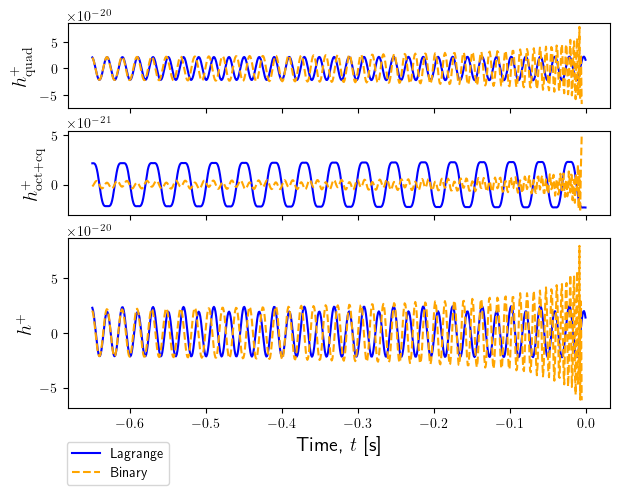

In [13]:
delta_t = 1/1000
t_max = 0.65

beta_1 = 0.015
M_3B = 50
quad_result = findQuadDegeneracy(*params_2B[:5], M_3B, beta_1)
params_3B_quad1 = [quad_result[0], M_3B*beta_1, M_3B*beta_1, M_3B*(1 - 2*beta_1), quad_result[1], 30, np.radians(288)]

hp_2B, hc_2B = waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t)
hp_3B, hc_3B = waveforms.h_combined3B(*params_3B_quad1, t_max = t_max, delta_t = delta_t)

waveforms.plot_waveform_time(params_2B, params_3B_quad1, t_max = t_max, delta_t = delta_t, radRxn = True, 
                             filename = "LaTeX Files/Figures/Quadrupole Degeneracy/Quadrupole degeneracy 1.pdf")

print("")
print("Binary Coalescence: {}".format(waveforms.CircularBinary(*params_2B).t_c))
print("Lagrange Triple Coalescence: {}".format(waveforms.CircularLagrangeTriple(*params_3B_quad1).t_c))
print("")

f_lower = 0
psd = pycbc.psd.analytical.aLIGOZeroDetHighPower(len(hp_2B) // 2 + 1, 1.0 / hp_2B.duration, f_lower)

pycbc.filter.match(hp_2B, hp_3B, psd = psd, low_frequency_cutoff = f_lower, subsample_interpolation = True)

/Users/cjdoctolero/Documents/College Stuff/Research/BS Physics Thesis/waveforms.py:52: RuntimeWarning: invalid value encountered in power
  return (5**(3/8))/8 * ((const.G*self.M_c/(const.c**3))**(-5/8)) * (self.t_c - t)**(-3/8)
/Users/cjdoctolero/Documents/College Stuff/Research/BS Physics Thesis/waveforms.py:56: RuntimeWarning: invalid value encountered in power
  return -(5**(-5/8)) * ((const.G*self.M_c/(const.c**3))**(-5/8)) * (self.t_c - t)**(5/8)


Binary Parameters:
l = 1.5e-11, m1 = 10, m2 = 8, r = 2000000.0, i = 30, phi = 0

Lagrange Three-Body Parameters:
l = 2.8231080866430836e-11, m1 = 1.7999999999999998, m2 = 1.7999999999999998, m3 = 116.39999999999999, r = 2740065.1206373814, i = 30, phi = 0.5585053606381855

Binary Coalescence: 0.6446118194246172
Lagrange Triple Coalescence: 0.9631873402104029



(np.float64(nan), np.float64(nan))

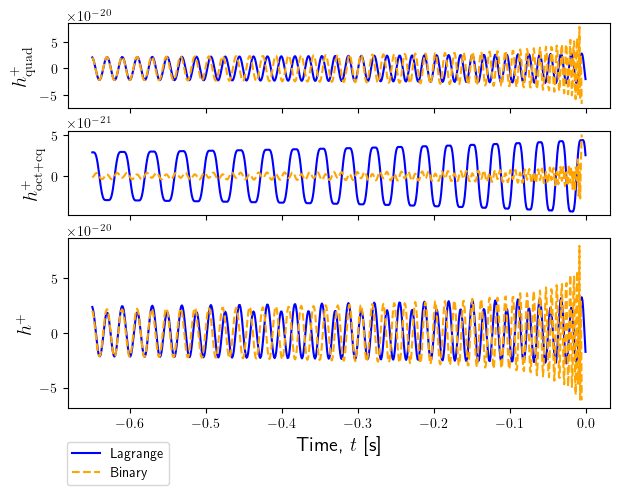

In [14]:
delta_t = 1/1000
t_max = 0.65

beta_1 = 0.015
M_3B = 120
quad_result = findQuadDegeneracy(*params_2B[:5], M_3B, beta_1)
params_3B_quad2 = [quad_result[0], M_3B*beta_1, M_3B*beta_1, M_3B*(1 - 2*beta_1), quad_result[1], 30, np.radians(32)]

hp_2B, hc_2B = waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t)
hp_3B, hc_3B = waveforms.h_combined3B(*params_3B_quad2, t_max = t_max, delta_t = delta_t)

waveforms.plot_waveform_time(params_2B, params_3B_quad2, t_max = t_max, delta_t = delta_t, radRxn = True,
                            filename = "LaTeX Files/Figures/Quadrupole Degeneracy/Quadrupole degeneracy 2.pdf")

print("")
print("Binary Coalescence: {}".format(waveforms.CircularBinary(*params_2B).t_c))
print("Lagrange Triple Coalescence: {}".format(waveforms.CircularLagrangeTriple(*params_3B_quad2).t_c))
print("")

f_lower = 0
psd = pycbc.psd.analytical.aLIGOZeroDetHighPower(len(hp_2B) // 2 + 1, 1.0 / hp_2B.duration, f_lower)

pycbc.filter.match(hp_2B, hp_3B, psd = psd, low_frequency_cutoff = f_lower, subsample_interpolation = True)

Binary Parameters:
l = 1.5e-11, m1 = 10, m2 = 8, r = 2000000.0, i = 30, phi = 0

Lagrange Three-Body Parameters:
l = 3.0411009977866976e-11, m1 = 2.25, m2 = 2.25, m3 = 145.5, r = 3974454.896038225, i = 30, phi = 1.710422666954443

Binary Coalescence: 0.6446118194246172
Lagrange Triple Coalescence: 0.6640397499996263



(np.float64(nan), np.float64(nan))

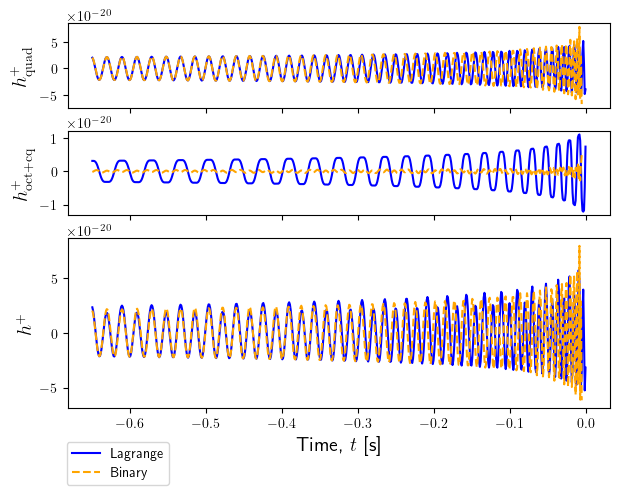

In [15]:
delta_t = 1/1000
t_max = 0.65

beta_1 = 0.015
M_3B = 150
quad_result = findQuadDegeneracy(*params_2B[:5], M_3B, beta_1)
params_3B_quad3 = [quad_result[0], M_3B*beta_1, M_3B*beta_1, M_3B*(1 - 2*beta_1), quad_result[1], 30, np.radians(98)]

hp_2B, hc_2B = waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t)
hp_3B, hc_3B = waveforms.h_combined3B(*params_3B_quad3, t_max = t_max, delta_t = delta_t)

waveforms.plot_waveform_time(params_2B, params_3B_quad3, t_max = t_max, delta_t = delta_t, radRxn = True,
                            filename = "LaTeX Files/Figures/Quadrupole Degeneracy/Quadrupole degeneracy 3.pdf")

print("")
print("Binary Coalescence: {}".format(waveforms.CircularBinary(*params_2B).t_c))
print("Lagrange Triple Coalescence: {}".format(waveforms.CircularLagrangeTriple(*params_3B_quad3).t_c))
print()

f_lower = 0
psd = pycbc.psd.analytical.aLIGOZeroDetHighPower(len(hp_2B) // 2 + 1, 1.0 / hp_2B.duration, f_lower)

pycbc.filter.match(hp_2B, hp_3B, psd = psd, low_frequency_cutoff = f_lower, subsample_interpolation = True)

We also perform the waveform match in the case where the binary and the Lagrange triple (with a total mass of 150 ${\mathrm{M}}_{\odot} \gg \mathcal{M}_{\mathrm{(2B)}} = 7.776$) have the same quadrupole waveforms and chirp mass. As a consequence of the latter, both waveforms have the same frequency sweep.

/Users/cjdoctolero/Documents/College Stuff/Research/BS Physics Thesis/waveforms.py:195: RuntimeWarning: invalid value encountered in power
  return (5**(3/8))/8 * ((const.G*self.M_c/(const.c**3))**(-5/8)) * (self.t_c - t)**(-3/8)
/Users/cjdoctolero/Documents/College Stuff/Research/BS Physics Thesis/waveforms.py:199: RuntimeWarning: invalid value encountered in power
  return -(5**(-5/8)) * ((const.G*self.M_c/(const.c**3))**(-5/8)) * (self.t_c - t)**(5/8)


Binary Parameters:
l = 1.5e-11, m1 = 10, m2 = 8, r = 2000000.0, i = 30, phi = 0

Lagrange Three-Body Parameters:
l = 3.0411009977866976e-11, m1 = 2.3231939027306483, m2 = 2.3231939027306483, m3 = 145.3536121945387, r = 4097455.9368759324, i = 30, phi = 3.141592653589793

Binary Coalescence: 0.6446118194246172
Lagrange Triple Coalescence: 0.6640397499996263



(np.float64(nan), np.float64(nan))

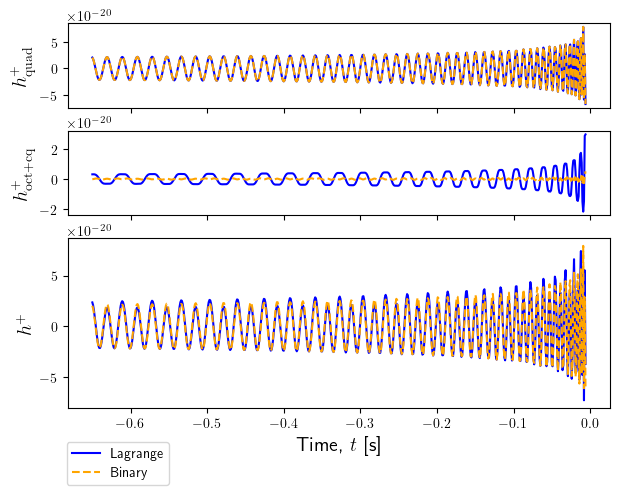

In [17]:
M_3B = 150
val = (waveforms.CircularBinary(*params_2B).M_c/sol)/M_3B

temp = poly.polyroots([-8*(val**5), 36*(val**5), -54*(val**5), 1 + 27*val**5, -18, 135, -540, 1215, -1458, 729])
temp = temp[np.isclose(temp.imag, 0)]
temp = temp[temp > 0]

beta_1 = np.real(np.min(temp))
quad_result = findQuadDegeneracy(*params_2B[:5], M_3B, beta_1)
params_3B_quad4 = [quad_result[0], M_3B*beta_1, M_3B*beta_1, M_3B*(1 - 2*beta_1), quad_result[1], 30, np.radians(180)]

hp_2B, hc_2B = waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t)
hp_3B, hc_3B = waveforms.h_combined3B(*params_3B_quad4, t_max = t_max, delta_t = delta_t)

waveforms.plot_waveform_time(params_2B, params_3B_quad4, t_max = t_max, delta_t = delta_t, radRxn = True,
                            filename = "LaTeX Files/Figures/Quadrupole Degeneracy/Quadrupole degeneracy 4.pdf")

print("")
print("Binary Coalescence: {}".format(waveforms.CircularBinary(*params_2B).t_c))
print("Lagrange Triple Coalescence: {}".format(waveforms.CircularLagrangeTriple(*params_3B_quad3).t_c))
print()

f_lower = 0
psd = pycbc.psd.analytical.aLIGOZeroDetHighPower(len(hp_2B) // 2 + 1, 1.0 / hp_2B.duration, f_lower)

pycbc.filter.match(hp_2B, hp_3B, psd = psd, low_frequency_cutoff = f_lower, subsample_interpolation = True)

A plot of the waveform match time series is shown below.

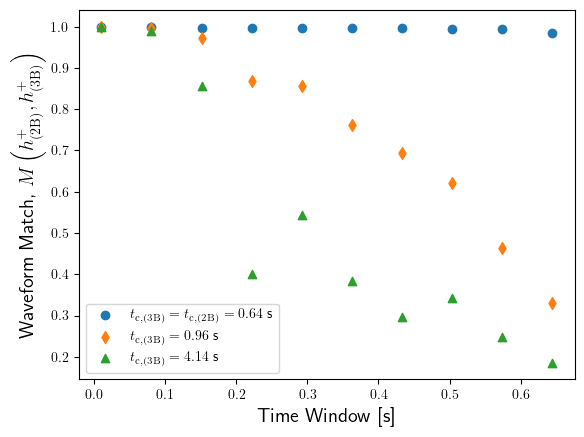

In [19]:
binary = waveforms.CircularBinary(*params_2B)
params_3B_quad = [params_3B_quad4, params_3B_quad2, params_3B_quad1]
markers = ["o", "d", "^", "X"]

t_window = np.linspace(0.01, binary.t_c, 10)

for i in range(len(params_3B_quad)):
    match_timeSeries = np.zeros(len(t_window))
    
    for j in range(len(t_window)):
        lagrange = waveforms.CircularLagrangeTriple(*params_3B_quad[i])
        
        hp_2B_windowed = waveforms.h_combined2B(*params_2B, t_max = t_window[j], delta_t = 1/1000)[0]
        hp_3B_windowed = waveforms.h_combined3B(*params_3B_quad[i], t_max = t_window[j], delta_t = 1/1000)[0]
        psd = pycbc.psd.analytical.aLIGOZeroDetHighPower(len(hp_2B_windowed) // 2 + 1, 1.0 / hp_2B_windowed.duration, 0)
        
        match_timeSeries[j] = pycbc.filter.match(hp_2B_windowed, hp_3B_windowed, psd = psd, low_frequency_cutoff = 0, subsample_interpolation = True)[0]

    if i == 0:
        #print(match_timeSeries)
        plt.scatter(t_window, match_timeSeries, label = r"$t_{{\mathrm{{c,(3B)}}}} = t_{{\mathrm{{c,(2B)}}}} = {:.2f}$ s".format(lagrange.t_c), marker = markers[i])
    else:
        plt.scatter(t_window, match_timeSeries, label = r"$t_{{\mathrm{{c,(3B)}}}} = {:.2f}$ s".format(lagrange.t_c), marker = markers[i])

plt.legend()
plt.xlabel("Time Window [s]", fontsize = "x-large")
plt.ylabel(r"Waveform Match, $M\left(h^{+}_{\mathrm{(2B)}}, h^{+}_{\mathrm{(3B)}}\right)$", fontsize = "x-large")

plt.savefig("LaTeX Files/Figures/Tests with LIGO PSD/Match time series for quadrupole degeneracy (scatter).pdf",
            bbox_inches = "tight")
plt.show()

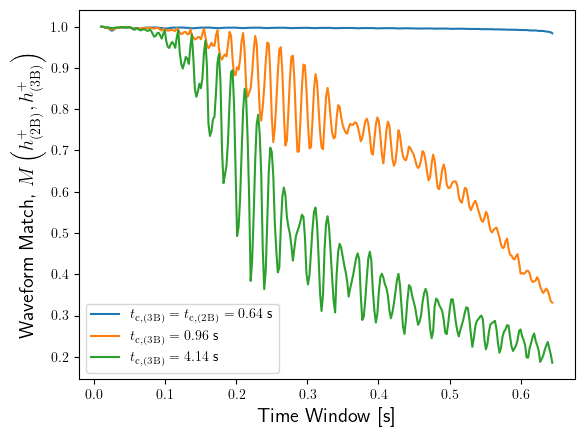

In [20]:
binary = waveforms.CircularBinary(*params_2B)
params_3B_quad = [params_3B_quad4, params_3B_quad2, params_3B_quad1]
markers = ["o", "d", "^", "X"]

t_window = np.linspace(0.01, binary.t_c, 300)

for i in range(len(params_3B_quad)):
    match_timeSeries = np.zeros(len(t_window))
    
    for j in range(len(t_window)):
        lagrange = waveforms.CircularLagrangeTriple(*params_3B_quad[i])
        
        hp_2B_windowed = waveforms.h_combined2B(*params_2B, t_max = t_window[j], delta_t = 1/1000)[0]
        hp_3B_windowed = waveforms.h_combined3B(*params_3B_quad[i], t_max = t_window[j], delta_t = 1/1000)[0]
        psd = pycbc.psd.analytical.aLIGOZeroDetHighPower(len(hp_2B_windowed) // 2 + 1, 1.0 / hp_2B_windowed.duration, 0)
        
        match_timeSeries[j] = pycbc.filter.match(hp_2B_windowed, hp_3B_windowed, psd = psd, low_frequency_cutoff = 0, subsample_interpolation = True)[0]

    if i == 0:
        #print(match_timeSeries)
        plt.plot(t_window, match_timeSeries, label = r"$t_{{\mathrm{{c,(3B)}}}} = t_{{\mathrm{{c,(2B)}}}} = {:.2f}$ s".format(lagrange.t_c))
    else:
        plt.plot(t_window, match_timeSeries, label = r"$t_{{\mathrm{{c,(3B)}}}} = {:.2f}$ s".format(lagrange.t_c))

plt.legend()
plt.xlabel("Time Window [s]", fontsize = "x-large")
plt.ylabel(r"Waveform Match, $M\left(h^{+}_{\mathrm{(2B)}}, h^{+}_{\mathrm{(3B)}}\right)$", fontsize = "x-large")

plt.savefig("LaTeX Files/Figures/Tests with LIGO PSD/Match time series for quadrupole degeneracy (line).pdf",
            bbox_inches = "tight")
plt.show()

## Waveform Degeneracy up to the 0.5PN Order

/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_72327/3095033961.py:17: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(num/denom)
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_72327/3095033961.py:20: RuntimeWarning: invalid value encountered in sqrt
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_72327/3095033961.py:20: RuntimeWarning: invalid value encountered in arcsin
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))


Min beta_1 for true degeneracy = 0.15909231818463634
Max beta_1 for true degeneracy = 0.20114840229680458
Binary Parameters:
l = 1.5e-11, m1 = 10, m2 = 8, r = 2000000.0, i = 30, phi = 0

Lagrange Three-Body Parameters:
l = 1.6736391668798657e-11, m1 = 3.9791550608070887, m2 = 3.9791550608070887, m3 = 17.04423502954566, r = 1329846.520426099, i = 2.645330218708403, phi = 3.0252373701235045

Binary Coalescence: 0.6446118194246172
Lagrange Triple Coalescence: 3.224776342568823



(np.float64(0.3561830039581144), np.float64(289.6536715901483))

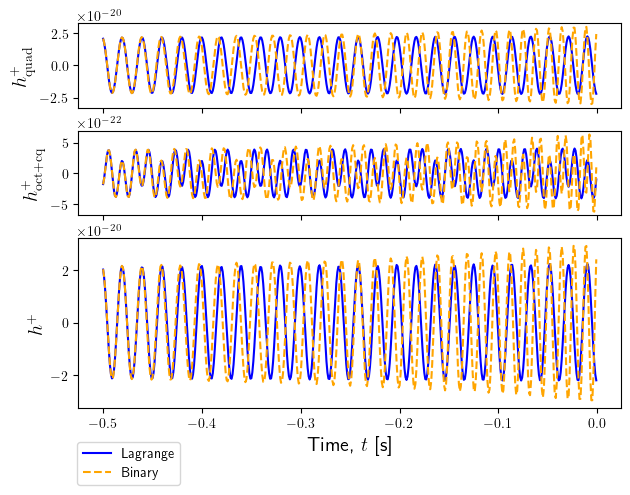

In [22]:
delta_t = 1/1000
t_max = 0.5

params_3B_oct1 = findOctDegeneracy(params_2B, 0.15915)

hp_2B, hc_2B = waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t)
hp_3B, hc_3B = waveforms.h_combined3B(*params_3B_oct1, t_max = t_max, delta_t = delta_t)

waveforms.plot_waveform_time(params_2B, params_3B_oct1, t_max = t_max, delta_t = delta_t, radRxn = True,
                            filename = "LaTeX Files/Figures/0.5PN Degeneracy/0.5PN degeneracy 1.pdf")

print("")
print("Binary Coalescence: {}".format(waveforms.CircularBinary(*params_2B).t_c))
print("Lagrange Triple Coalescence: {}".format(waveforms.CircularLagrangeTriple(*params_3B_oct1).t_c))
print("")

f_lower = 0
psd = pycbc.psd.analytical.aLIGOZeroDetHighPower(len(hp_2B) // 2 + 1, 1.0 / hp_2B.duration, f_lower)

pycbc.filter.match(hp_2B, hp_3B, psd = psd, low_frequency_cutoff = f_lower, subsample_interpolation = True)

/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_72327/3095033961.py:17: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(num/denom)
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_72327/3095033961.py:20: RuntimeWarning: invalid value encountered in sqrt
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_72327/3095033961.py:20: RuntimeWarning: invalid value encountered in arcsin
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))


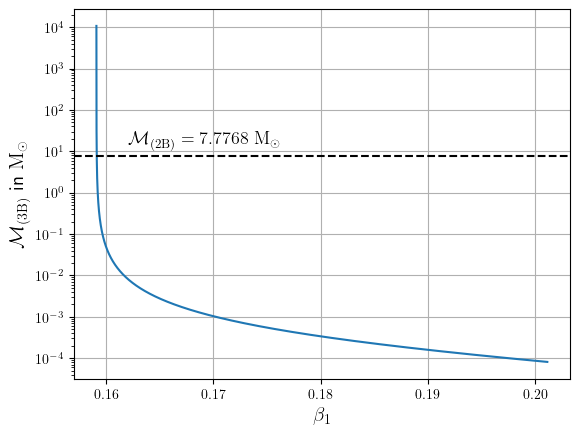

In [23]:
#generate the data
delta_t = 1/1000
t_max = 0.5
binary = waveforms.CircularBinary(*params_2B)

ratio_w_3w = binary.h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "plus")[0]/binary.h_octcq(t_max = t_max, delta_t = delta_t, ampOnly = True, pol = "plus")[1]

b1 = np.linspace(0, 1, 1000000)
i_3B = iota(b1, b1, ratio_w_3w)
i_3B[b1 > 0.5] = np.nan

#find the values of b1 where i_3B is defined (i.e., the values of b1 that are part of the domain of i_3B)
b1_filtered = b1[np.where(~np.isnan(i_3B))]

plt.plot(b1_filtered, (find_M_3B(*params_2B, b1_filtered)/sol)*((b1_filtered*((1 - 3*b1_filtered)**2))/(2 - 3*b1_filtered))**(3/5))
plt.axhline(binary.M_c/sol, color = "black", ls = "dashed")
plt.annotate(r"$\mathcal{{M}}_{{\mathrm{{(2B)}}}} = {:.4f} \ \mathrm{{M}}_{{\odot}}$".format(binary.M_c/sol), xy = (0.162, 15), fontsize = 13)
plt.xlabel(r"$\beta_1$", fontsize = "x-large")
plt.ylabel(r"$\mathcal{M}_{\mathrm{(3B)}}$ in $\mathrm{M}_{\odot}$", fontsize = "x-large")
plt.grid()
plt.gca().set_axisbelow(True)
plt.yscale("log")

plt.savefig("LaTeX Files/Figures/Chirp Mass/M_chirp vs beta_1.pdf", bbox_inches = "tight")
plt.show()

In [24]:
binary.M_c/sol

7.776774233174123

In [25]:
for beta_1 in np.linspace(0.15912194481944822, 0.1591219536000439, 100000)[50000:60000]:
    print(beta_1, (find_M_3B(*params_2B, beta_1)/sol)*((beta_1*(1 - 3*beta_1)**2)/(2 - 3*beta_1))**(3/5))

0.15912194920978998 7.7768882353642095
0.15912194920987777 7.7768882023546935
0.15912194920996559 7.776888169345176
0.1591219492100534 7.776888136335652
0.1591219492101412 7.776888103330771
0.159121949210229 7.776888070316623
0.1591219492103168 7.77688803732563
0.15912194921040462 7.776888004311479
0.1591219492104924 7.776887971306596
0.15912194921058023 7.776887938310967
0.15912194921066805 7.776887905292201
0.15912194921075584 7.7768878722873085
0.15912194921084366 7.776887839270849
0.15912194921093145 7.776887806265965
0.15912194921101927 7.776887773261076
0.15912194921110706 7.77688774026082
0.15912194921119488 7.776887707255941
0.1591219492112827 7.776887674237163
0.1591219492113705 7.776887641241539
0.1591219492114583 7.776887608236647
0.1591219492115461 7.77688757523177
0.15912194921163392 7.776887542217627
0.1591219492117217 7.776887509217374
0.15912194921180953 7.776887476203236
0.15912194921189735 7.7768874431937185
0.15912194921198514 7.776887410198108
0.15912194921207296 7.

In [26]:
for beta_1 in np.linspace(0.1591219495130748, 0.15912194951289915, 100000)[1000:1500]:
    print(beta_1, (find_M_3B(*params_2B, beta_1)/sol)*((beta_1*(1 - 3*beta_1)**2)/(2 - 3*beta_1))**(3/5))

0.15912194951307304 7.776774233119908
0.15912194951307304 7.776774233119908
0.15912194951307304 7.776774233119908
0.15912194951307304 7.776774233119908
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.159121949513073 7.776774233129169
0.15912194951307299 7.776774233133802
0.15912194951307299 7.776774233133802
0.15912194951307299 7.776774233133802
0.15912194951307299 7.776774233133802
0.15912194951307299 7.776774233133802
0.15912194951307299 7.776774233133802
0.15912194951307299 7.776774233133802
0.1591

/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_72327/3095033961.py:17: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(num/denom)
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_72327/3095033961.py:20: RuntimeWarning: invalid value encountered in sqrt
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_72327/3095033961.py:20: RuntimeWarning: invalid value encountered in arcsin
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))


Min beta_1 for true degeneracy = 0.15909231818463634
Max beta_1 for true degeneracy = 0.20114840229680458
Binary Parameters:
l = 1.5e-11, m1 = 10, m2 = 8, r = 2000000.0, i = 30, phi = 0

Lagrange Three-Body Parameters:
l = 2.309373805332004e-11, m1 = 10.452291790150664, m2 = 10.452291790150664, m3 = 44.78271991324934, r = 6655437.262202962, i = 1.917277536430065, phi = 3.1573163405446967

Binary Coalescence: 0.6446118194246172
Lagrange Triple Coalescence: 0.644611819425072



(np.float64(nan), np.float64(nan))

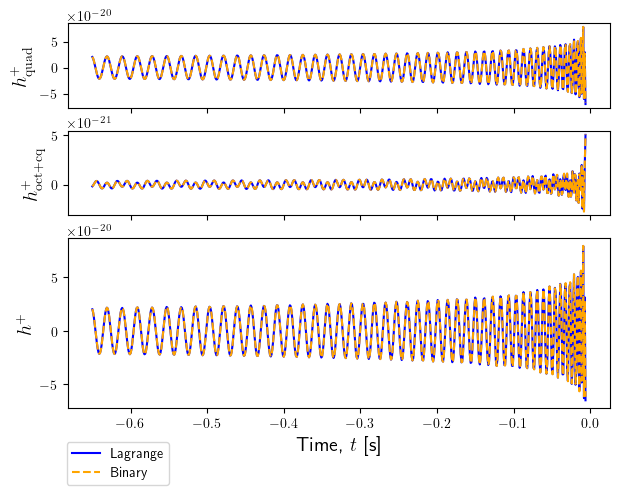

In [27]:
delta_t = 1/1000
t_max = 0.65

params_3B_oct1 = findOctDegeneracy(params_2B, 0.15912194951307287)

hp_2B, hc_2B = waveforms.h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t)
hp_3B, hc_3B = waveforms.h_combined3B(*params_3B_oct1, t_max = t_max, delta_t = delta_t)

waveforms.plot_waveform_time(params_2B, params_3B_oct1, t_max = t_max, delta_t = delta_t, radRxn = True,
                            filename = "LaTeX Files/Figures/0.5PN Degeneracy/0.5PN degeneracy 2.pdf")

print("")
print("Binary Coalescence: {}".format(waveforms.CircularBinary(*params_2B).t_c))
print("Lagrange Triple Coalescence: {}".format(waveforms.CircularLagrangeTriple(*params_3B_oct1).t_c))
print("")

f_lower = 0
psd = pycbc.psd.analytical.aLIGOZeroDetHighPower(len(hp_2B) // 2 + 1, 1.0 / hp_2B.duration, f_lower)

pycbc.filter.match(hp_2B, hp_3B, psd = psd, low_frequency_cutoff = f_lower, subsample_interpolation = True)

# 4: Signal-to-Noise Ratio (SNR) Calculations

In reality, the GW signal is buried under colored noise, i.e., background noise that is frequency-dependent. Using the LIGO noise curve, we can generate a colored noise that covers the signal we generated earlier. We follow this __[notebook](https://github.com/gw-odw/odw-2023/blob/main/Tutorials/Day_2/Tuto_2.1_Matched_filtering_introduction.ipynb)__ for generating the colored noise and whitening the noise.

In [ ]:
#generate the waveform
delta_t = 1/1000
t_max = 12

params_2B = [1e-11, 2.3, 1.6, 5e9, 75, 0]

hp_2B, hc_2B = h_combined2B(*params_2B, t_max = t_max, delta_t = delta_t)

# The color of the noise matches a PSD which you provide:
# Generate a PSD matching Advanced LIGO's zero-detuned--high-power noise curve
sample_rate = int(1/delta_t)
data_length = len(hp_2B.sample_times)
f_low = 10
f_len = int(sample_rate / (2 * hp_2B.delta_f)) + 1
psd = pycbc.psd.aLIGOZeroDetHighPower(f_len, hp_2B.delta_f, f_low)

noise = pycbc.noise.noise_from_psd(data_length*sample_rate, delta_t, psd, seed = 127)

# Estimate the amplitude spectral density (ASD = sqrt(PSD)) for the noisy data 
# using the "welch" method. We'll choose 4 seconds PSD samples that are overlapped 50%
seg_len = int(4/delta_t)
seg_stride = int(seg_len/2)
estimated_psd = pycbc.psd.welch(noise, seg_len = seg_len, seg_stride = seg_stride)

plt.loglog(estimated_psd.sample_frequencies, estimated_psd, label = "Estimate")
plt.loglog(psd.sample_frequencies, psd, label = "Known PSD")
plt.xlim(xmin=f_low, xmax=512)
plt.ylim(1e-47, 1e-45)
plt.xlabel("Frequency [Hz]", fontsize = "x-large")
plt.ylabel("Noise spectral density", fontsize = "x-large")
plt.legend()
plt.grid()
plt.show()

#add the signal to the noise to generate an artificial strain detection
waveform_start = np.random.randint(0, len(noise) - len(hp_2B))
data = noise[waveform_start:waveform_start + len(hp_2B)] + hp_2B.numpy()

plt.plot(hp_2B.sample_times, data)
plt.xlabel(r"Observer time, $t$ [s]", fontsize = "x-large")
plt.ylabel(r"Strain, $s(t)$", fontsize = "x-large")
plt.show()
plt.show()

We now whiten the data in the frequency domain.

In [ ]:
snr = pycbc.filter.matched_filter(hp_3B, data, psd = psd, low_frequency_cutoff = 10)

plt.plot(snr.sample_times, abs(snr))
plt.xlabel("Time (s)")
plt.ylabel("Signal-to-noise")
plt.show()